In [ ]:
import torch
import hashlib
import numpy as np
from transformers import LogitsProcessor, LogitsProcessorList
from scipy.stats import norm
class GreenListWatermarkProcessor(LogitsProcessor):
  def __init__(self, vocab_size, secret_key, gamma=0.5, delta=2.0, k=1):
    self.vocab_size = vocab_size
    self.secret_key = secret_key # Add secret_key
    self.gamma = gamma
    self.delta = delta
    self.k = k
    if not (0 <= gamma <= 1):
        raise ValueError("gamma must be between 0 and 1")

  def __call__(self, input_ids: torch.LongTensor, scores: torch.FloatTensor) -> torch.FloatTensor:

    # Assuming batch_size = 1 for simplicity in watermarking context
    if input_ids.shape[0] != 1:
        raise ValueError("GreenListWatermarkProcessor is designed for batch_size=1")

    prev_token = input_ids[0, -self.k:].tolist()

    # Generate a seed using hashlib.sha256 for PRF key
    combined_input = str(self.secret_key).encode('utf-8') + str(prev_token).encode('utf-8')
    seed = int(hashlib.sha256(combined_input).hexdigest(), 16) % (2**32 - 1)

    # Initialize a numpy random number generator with the context-dependent seed
    rng = np.random.default_rng(seed)

    # Determine the number of tokens to greenlist
    num_green_tokens = int(self.vocab_size * self.gamma)

    # Create a permutation of all token IDs
    all_tokens = np.arange(self.vocab_size)
    shuffled_tokens = rng.permutation(all_tokens)

    # Select green and red tokens for the current step
    green_list_tokens = shuffled_tokens[:num_green_tokens]
    # red_list_tokens = shuffled_tokens[num_green_tokens:] # Not needed if only boosting green list

    # Apply positive bias to green-listed tokens' logits
    # Create a boolean mask for green-listed tokens in the current vocabulary dimension
    green_mask = torch.zeros_like(scores, dtype=torch.bool, device=scores.device)
    green_mask[0, green_list_tokens] = True # Apply to the single batch item

    scores[green_mask] += self.delta

    return scores

In [ ]:
import torch
import hashlib
import numpy as np
from transformers import LogitsProcessor, LogitsProcessorList
from scipy.stats import norm
class WatermarkDetector:
  def __init__(self, vocab_size, tokenizer, secret_key, gamma=0.5, delta=2.0, k=1):
    self.vocab_size = vocab_size
    self.gamma = gamma
    self.delta = delta
    self.k = k
    self.tokenizer = tokenizer
    self.secret_key = secret_key # Add secret_key
    self.device = 0 if torch.cuda.is_available() else -1
    if not (0 <= gamma <= 1):
        raise ValueError("gamma must be between 0 and 1")
  def __call__(self, generated_text):
    tokens = self.tokenizer.encode(generated_text)
    green_count = 0
    for i in range(len(tokens) - self.k):
      input_ids = torch.tensor([tokens[i:i+self.k]])
      scores = torch.zeros((1, self.vocab_size))
      prev_token = input_ids[0].tolist()

      # Generate a seed using hashlib.sha256 for PRF key, matching the processor
      combined_input = str(self.secret_key).encode('utf-8') + str(prev_token).encode('utf-8')
      seed = int(hashlib.sha256(combined_input).hexdigest(), 16) % (2**32 - 1) # Use a large prime modulo for seed

      # Initialize a numpy random number generator with the context-dependent seed
      rng = np.random.default_rng(seed)

      # Determine the number of tokens to greenlist
      num_green_tokens = int(self.vocab_size * self.gamma)

      # Create a permutation of all token IDs
      all_tokens = np.arange(self.vocab_size)
      shuffled_tokens = rng.permutation(all_tokens)

      # Select green and red tokens for the current step
      green_list_tokens = shuffled_tokens[:num_green_tokens]
      # red_list_tokens = shuffled_tokens[num_green_tokens:] # Not needed if only boosting green list

      # Apply positive bias to green-listed tokens' logits
      # Create a boolean mask for green-listed tokens in the current vocabulary dimension
      green_mask = torch.zeros_like(scores, dtype=torch.bool, device=self.device)
      green_mask[0, green_list_tokens] = True # Apply to the single batch item
      next_token = tokens[i+self.k]
      green_count+= int(green_mask[0, next_token].item())

    T = len(tokens)
    # Calculate the z-score
    z_score = (green_count - T * self.gamma)/np.sqrt(T * self.gamma * (1 - self.gamma))
    p = norm.sf(z_score)
    return z_score, p

In [ ]:
class ParaphraseAttack:
  def __init__(self, pipeline):
    self.pipeline = pipeline
    self.template = """Rewrite naturally and feel free to change words wherever possible:
      {text}

      Paraphrase:
    """
  def __call__(self, text):
    prompt = self.template.format(text=text)
    return self.pipeline.generate(prompt)

In [ ]:
from math import log
class QWENPipeline:
  def __init__(self, model, tokenizer, processor=None):
    self.model = model
    self.tokenizer = tokenizer
    self.processor = processor

  def get_log_probs(self, prompt, target_token):
    messages = [
      {"role": "user", "content": prompt}
    ]
    text = self.tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    model_inputs = self.tokenizer([text], return_tensors="pt").to(self.model.device)
    output = self.model(
        **model_inputs
    )
    log_probs = torch.log_softmax(output.logits, dim=-1)
    probs = torch.softmax(output.logits, dim=-1)
    log_probs_last_token = log_probs[0, -1, :]
    target_token_id = self.tokenizer.encode(target_token)[0]
    log_prob_target_token = log_probs_last_token[target_token_id]
    return log_prob_target_token
  def generate(self, prompt, watermark=True, **kwargs):
    messages = [
      {"role": "user", "content": prompt}
    ]
    text = self.tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False
    )
    model_inputs = self.tokenizer([text], return_tensors="pt").to(self.model.device)
    # conduct text completion

    generated_ids = self.model.generate(
        **model_inputs,
        max_new_tokens=256,
        logits_processor=LogitsProcessorList([self.processor]) if (self.processor and watermark) else None,
    )
    output_ids = generated_ids[0][len(model_inputs.input_ids[0]):].tolist()
    content = self.tokenizer.decode(output_ids, skip_special_tokens=True).strip("\n")
    return content

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
device = 0 if torch.cuda.is_available() else -1
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-4B")
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen3-4B").to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [ ]:
tokenizer_qwen_mini = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct")
model_qwen_mini = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct").to(device)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [ ]:
secret_key = "my_secret_key"
processor = GreenListWatermarkProcessor(
  vocab_size=model.config.vocab_size,
  secret_key=secret_key,
  gamma=0.5, delta=2.0, k=1,
)
pipeline = QWENPipeline(model, tokenizer, processor)
pipeline_mini = QWENPipeline(model_qwen_mini, tokenizer_qwen_mini, processor=None)

In [ ]:
from datasets import load_dataset

ds = load_dataset("databricks/databricks-dolly-15k")

README.md: 0.00B [00:00, ?B/s]

databricks-dolly-15k.jsonl:   0%|          | 0.00/13.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15011 [00:00<?, ? examples/s]

In [ ]:
detector = WatermarkDetector(
  vocab_size=model.config.vocab_size,
  tokenizer=tokenizer,
  gamma=0.5, delta=2.0, k=1,secret_key=secret_key,
  hashcode=1000003
)


In [ ]:
from datasets import Dataset

categories = ds['train'].unique('category')
sampled_data_list = []
num_samples_per_category = 15

for category in categories:
    # Filter by category, shuffle, and select N samples
    category_samples = ds['train'].filter(lambda x: x['category'] == category).shuffle(seed=42).select(range(num_samples_per_category))
    sampled_data_list.extend(category_samples)

# Convert the list of dictionaries back to a Dataset object
sampled_data = Dataset.from_list(sampled_data_list)

print(f"Sampled {len(sampled_data)} points from the dataset ({num_samples_per_category} from each category, or fewer if a category has less).")
print(sampled_data[0])

# Calculate response token counts for each category in the full dataset
category_token_counts = {}
category_response_counts = {}

for category in categories:
    category_token_counts[category] = 0
    category_response_counts[category] = 0

    # Filter the original 'train' split by category
    category_data = ds['train'].filter(lambda x: x['category'] == category)

    for item in category_data:
        response = item['response']
        # Tokenize the response using the pre-loaded tokenizer
        tokens = tokenizer.encode(response)
        category_token_counts[category] += len(tokens)
        category_response_counts[category] += 1

# Calculate average token count per category
average_token_counts = {}
for category in categories:
    if category_response_counts[category] > 0:
        average_token_counts[category] = category_token_counts[category] / category_response_counts[category]
    else:
        average_token_counts[category] = 0

# Find category with the least and most average response tokens
if average_token_counts:
    least_tokens_category = min(average_token_counts, key=average_token_counts.get)
    most_tokens_category = max(average_token_counts, key=average_token_counts.get)

    print(f"\nCategory with the least average response tokens: '{least_tokens_category}' (Average: {average_token_counts[least_tokens_category]:.2f} tokens)")
    print(f"Category with the most average response tokens: '{most_tokens_category}' (Average: {average_token_counts[most_tokens_category]:.2f} tokens)")
else:
    print("No categories found or no responses in categories to analyze.")

Sampled 120 points from the dataset (15 from each category, or fewer if a category has less).
{'instruction': 'When did the maximum rate of water usage begin to be mandated?', 'context': 'A low-flow fixture is a water saving plumbing fixture designed to achieve water savings by having a lower flow rate of water or a smaller quantity per flush. Some of these low-flow fixtures are faucets, showerheads, and toilets. In the United States a maximum water usage of conventional plumbing fixtures was federally mandated by the Energy policy act of 1992. Low-flow fixtures are designed to save water over conventional fixtures by having a lower flow rate while still maintaining satisfactory performance. The Environmental protection agency (EPA) WaterSense program has requirements for plumbing fixtures to achieve their definition for water saving low-flow.', 'response': '1992', 'category': 'closed_qa'}


Filter:   0%|          | 0/15011 [00:00<?, ? examples/s]

Filter:   0%|          | 0/15011 [00:00<?, ? examples/s]

Filter:   0%|          | 0/15011 [00:00<?, ? examples/s]

Filter:   0%|          | 0/15011 [00:00<?, ? examples/s]

Filter:   0%|          | 0/15011 [00:00<?, ? examples/s]

Filter:   0%|          | 0/15011 [00:00<?, ? examples/s]

Filter:   0%|          | 0/15011 [00:00<?, ? examples/s]

Filter:   0%|          | 0/15011 [00:00<?, ? examples/s]


Category with the least average response tokens: 'classification' (Average: 35.80 tokens)
Category with the most average response tokens: 'creative_writing' (Average: 216.31 tokens)


In [ ]:
attack = ParaphraseAttack(pipeline_mini)

In [ ]:
from tqdm.auto import tqdm
import pandas as pd

pbar = tqdm(
    sampled_data,
    desc="Processing generations"
)

human_z_scores = []
human_p_values = []
wm_z_scores = []
wm_p_values = []
nwm_z_scores = []
nwm_p_values = []
paraphrase_z_scores = []
paraphrase_p_values = []

wm_success = 0
nwm_success = 0
paraphrase_success = 0
total_processed = 0

# Wrap the dataset iteration with tqdm for a progress bar
for points in pbar:
  total_processed += 1

  # Human response
  z_human, p_human = detector(generated_text=points['response'])
  human_z_scores.append(z_human)
  human_p_values.append(p_human)

  # Watermarked response
  generated_wm_text = pipeline.generate(points['instruction'], watermark=True)
  z_wm, p_wm = detector(generated_text=generated_wm_text)
  wm_z_scores.append(z_wm)
  wm_p_values.append(p_wm)
  if p_wm < 0.01: # Success threshold for watermarked content
    wm_success += 1

  # Non-watermarked response
  generated_nwm_text = pipeline.generate(points['instruction'], watermark=False)
  z_nwm, p_nwm = detector(generated_text=generated_nwm_text)
  nwm_z_scores.append(z_nwm)
  nwm_p_values.append(p_nwm)
  if p_nwm < 0.01: # Success threshold for non-watermarked content (should be low)
    nwm_success += 1

  # Paraphrase attack
  paraphrase_text = attack(points['response'])
  z_paraphrase, p_paraphrase = detector(generated_text=paraphrase_text)
  paraphrase_z_scores.append(z_paraphrase)
  paraphrase_p_values.append(p_paraphrase)

  if p_paraphrase < 0.01:
    paraphrase_success += 1

  # Update the tqdm postfix with the running success rate
  if total_processed > 0:
    pbar.set_postfix(
        wm_success_rate=f"{wm_success/total_processed:.2f}",
        nwm_success_rate=f"{nwm_success/total_processed:.2f}",
        paraphrase_success_rate=f"{paraphrase_success/total_processed:.2f}"
    )

if len(sampled_data) > 0:
  print(f"\nFinal Watermarked Success Rate (p < 0.01): {wm_success/len(sampled_data):.2f}")
  print(f"Final Non-Watermarked Success Rate (p < 0.01): {nwm_success/len(sampled_data):.2f}")
  print(f"Final Paraphrase Attack Success Rate (p < 0.01): {paraphrase_success/len(sampled_data):.2f}")

  # Create a DataFrame for easy comparison and visualization
  evaluation_df = pd.DataFrame({
      'human_z_score': human_z_scores,
      'human_p_value': human_p_values,
      'watermarked_z_score': wm_z_scores,
      'watermarked_p_value': wm_p_values,
      'non_watermarked_z_score': nwm_z_scores,
      'non_watermarked_p_value': nwm_p_values,
      'paraphrase_z_score': paraphrase_z_scores,
      'paraphrase_p_value': paraphrase_p_values,
  })
  display(evaluation_df.head())
else:
  print("No data to process.")

Processing generations:   0%|          | 0/120 [00:00<?, ?it/s]


Final Watermarked Success Rate (p < 0.01): 0.53
Final Non-Watermarked Success Rate (p < 0.01): 0.02
Final Paraphrase Attack Success Rate (p < 0.01): 0.03


,human_z_score,human_p_value,watermarked_z_score,watermarked_p_value,non_watermarked_z_score,non_watermarked_p_value,paraphrase_z_score,paraphrase_p_value
0,1.000000,0.158655,2.750000,0.002980,-1.000000,0.841345,1.000000,0.158655
1,-1.632993,0.948765,-0.174078,0.569098,-0.522233,0.699246,-0.577350,0.718149
2,0.000000,0.500000,0.160128,0.436390,0.160128,0.436390,0.192450,0.423695
3,2.253086,0.012127,4.375000,0.000006,1.500000,0.066807,1.750000,0.040059
4,0.365148,0.357500,3.625000,0.000144,2.250000,0.012224,0.522233,0.300754


In [ ]:
evaluation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   human_z_score            120 non-null    float64
 1   human_p_value            120 non-null    float64
 2   watermarked_z_score      120 non-null    float64
 3   watermarked_p_value      120 non-null    float64
 4   non_watermarked_z_score  120 non-null    float64
 5   non_watermarked_p_value  120 non-null    float64
 6   paraphrase_z_score       120 non-null    float64
 7   paraphrase_p_value       120 non-null    float64
dtypes: float64(8)
memory usage: 7.6 KB


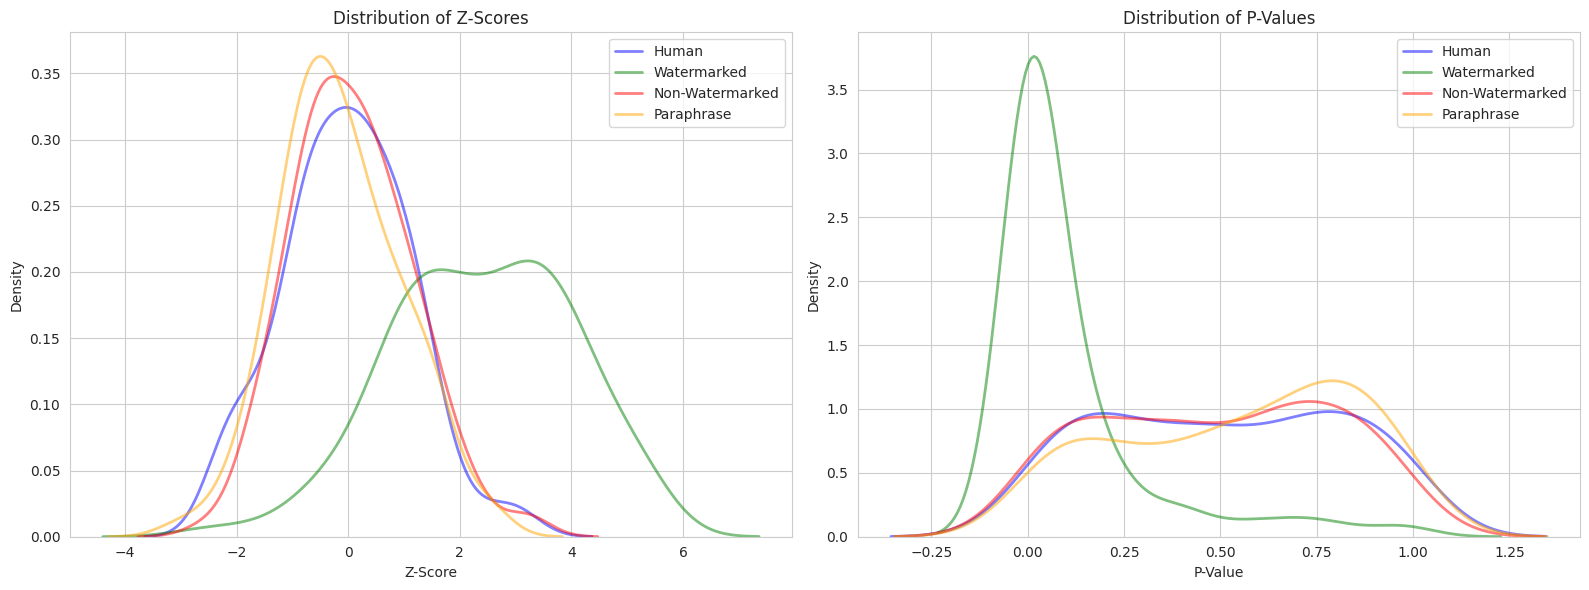

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plotting Z-Scores
sns.kdeplot(evaluation_df['human_z_score'], color='blue', label='Human', ax=axes[0], fill=False, alpha=0.5, linewidth=2)
sns.kdeplot(evaluation_df['watermarked_z_score'], color='green', label='Watermarked', ax=axes[0], fill=False, alpha=0.5, linewidth=2)
sns.kdeplot(evaluation_df['non_watermarked_z_score'], color='red', label='Non-Watermarked', ax=axes[0], fill=False, alpha=0.5, linewidth=2)
sns.kdeplot(evaluation_df['paraphrase_z_score'], color='orange', label='Paraphrase', ax=axes[0], fill=False, alpha=0.5, linewidth=2)
axes[0].set_title('Distribution of Z-Scores')
axes[0].set_xlabel('Z-Score')
axes[0].set_ylabel('Density')
axes[0].legend()

# Plotting P-Values
sns.kdeplot(evaluation_df['human_p_value'], color='blue', label='Human', ax=axes[1], fill=False, alpha=0.5, linewidth=2)
sns.kdeplot(evaluation_df['watermarked_p_value'], color='green', label='Watermarked', ax=axes[1], fill=False, alpha=0.5, linewidth=2)
sns.kdeplot(evaluation_df['non_watermarked_p_value'], color='red', label='Non-Watermarked', ax=axes[1], fill=False, alpha=0.5, linewidth=2)
sns.kdeplot(evaluation_df['paraphrase_p_value'], color='orange', label='Paraphrase', ax=axes[1], fill=False, alpha=0.5, linewidth=2)
axes[1].set_title('Distribution of P-Values')
axes[1].set_xlabel('P-Value')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
evaluation_df.to_csv('evaluation_results.csv', index=False)

### Sampling 30 points each from 'classification' and 'creative_writing'

In [ ]:
from datasets import Dataset

specific_categories = ['classification', 'creative_writing']
new_sampled_data_list = []
num_samples_per_specific_category = 30

for category in specific_categories:
    # Filter by category, shuffle, and select N samples
    category_samples = ds['train'].filter(lambda x: x['category'] == category).shuffle(seed=42).select(range(num_samples_per_specific_category))
    new_sampled_data_list.extend(category_samples)

# Convert the list of dictionaries back to a Dataset object
new_sampled_data = Dataset.from_list(new_sampled_data_list)

print(f"Sampled {len(new_sampled_data)} points from the dataset ({num_samples_per_specific_category} from each specified category, or fewer if a category has less).")
print(new_sampled_data[0])

Sampled 60 points from the dataset (30 from each specified category, or fewer if a category has less).
{'instruction': 'Identify which car manufacturer is Japanese or American: Isuzu, Cadillac', 'context': '', 'response': 'Isuzu is Japanese, Cadillac is American', 'category': 'classification'}


### Comparing Watermarking Detection for 'classification' and 'creative_writing' Categories

In [ ]:
from tqdm.auto import tqdm
import pandas as pd

pbar_new = tqdm(
    new_sampled_data,
    desc="Processing new sampled generations"
)

new_human_z_scores = []
new_human_p_values = []
new_wm_z_scores = []
new_wm_p_values = []
new_nwm_z_scores = []
new_nwm_p_values = []
new_paraphrase_z_scores = []
new_paraphrase_p_values = []
new_categories = [] # To store categories for each sampled point

new_wm_success = 0
new_nwm_success = 0
new_paraphrase_success = 0
new_total_processed = 0

for points in pbar_new:
  new_total_processed += 1
  new_categories.append(points['category']) # Store the category

  # Human response
  z_human, p_human = detector(generated_text=points['response'])
  new_human_z_scores.append(z_human)
  new_human_p_values.append(p_human)

  # Watermarked response
  generated_wm_text = pipeline.generate(points['instruction'], watermark=True)
  z_wm, p_wm = detector(generated_text=generated_wm_text)
  new_wm_z_scores.append(z_wm)
  new_wm_p_values.append(p_wm)
  if p_wm < 0.01: # Success threshold for watermarked content
    new_wm_success += 1

  # Non-watermarked response
  generated_nwm_text = pipeline.generate(points['instruction'], watermark=False)
  z_nwm, p_nwm = detector(generated_text=generated_nwm_text)
  new_nwm_z_scores.append(z_nwm)
  new_nwm_p_values.append(p_nwm)
  if p_nwm < 0.01: # Success threshold for non-watermarked content (should be low)
    new_nwm_success += 1

  # Paraphrase attack
  paraphrase_text = attack(points['response'])
  z_paraphrase, p_paraphrase = detector(generated_text=paraphrase_text)
  new_paraphrase_z_scores.append(z_paraphrase)
  new_paraphrase_p_values.append(p_paraphrase)

  if p_paraphrase < 0.01:
    new_paraphrase_success += 1

  # Update the tqdm postfix with the running success rate
  if new_total_processed > 0:
    pbar_new.set_postfix(
        wm_success_rate=f"{new_wm_success/new_total_processed:.2f}",
        nwm_success_rate=f"{new_nwm_success/new_total_processed:.2f}",
        paraphrase_success_rate=f"{new_paraphrase_success/new_total_processed:.2f}"
    )

if len(new_sampled_data) > 0:
  print(f"\nFinal Watermarked Success Rate (p < 0.01) for new sample: {new_wm_success/len(new_sampled_data):.2f}")
  print(f"Final Non-Watermarked Success Rate (p < 0.01) for new sample: {new_nwm_success/len(new_sampled_data):.2f}")
  print(f"Final Paraphrase Attack Success Rate (p < 0.01) for new sample: {new_paraphrase_success/len(new_sampled_data):.2f}")

  # Create a DataFrame for easy comparison and visualization
  new_evaluation_df = pd.DataFrame({
      'category': new_categories, # Include category in the DataFrame
      'human_z_score': new_human_z_scores,
      'human_p_value': new_human_p_values,
      'watermarked_z_score': new_wm_z_scores,
      'watermarked_p_value': new_wm_p_values,
      'non_watermarked_z_score': new_nwm_z_scores,
      'non_watermarked_p_value': new_nwm_p_values,
      'paraphrase_z_score': new_paraphrase_z_scores,
      'paraphrase_p_value': new_paraphrase_p_values,
  })
  display(new_evaluation_df.head())
else:
  print("No data to process in the new sample.")

Processing new sampled generations:   0%|          | 0/60 [00:00<?, ?it/s]


Final Watermarked Success Rate (p < 0.01) for new sample: 0.55
Final Non-Watermarked Success Rate (p < 0.01) for new sample: 0.08
Final Paraphrase Attack Success Rate (p < 0.01) for new sample: 0.00


,category,human_z_score,human_p_value,watermarked_z_score,watermarked_p_value,non_watermarked_z_score,non_watermarked_p_value,paraphrase_z_score,paraphrase_p_value
0,classification,1.414214,0.078650,3.354895,0.000397,2.190890,0.014230,-1.069045,0.857475
1,classification,0.000000,0.500000,3.095208,0.000983,-0.375000,0.646170,0.000000,0.500000
2,classification,0.000000,0.500000,1.410048,0.079263,0.862662,0.194162,0.333333,0.369441
3,classification,-1.897367,0.971110,1.000000,0.158655,1.402136,0.080437,-1.929528,0.973167
4,classification,3.063165,0.001095,1.037513,0.149748,-0.226779,0.589702,-0.648886,0.741794


### Detailed Comparison of Watermarking Metrics by Category

In [ ]:
print("\n--- Watermarking Metrics per Category ---")
for category in specific_categories:
    category_df = new_evaluation_df[new_evaluation_df['category'] == category]
    if not category_df.empty:
        print(f"\nCategory: {category}")
        total_samples = len(category_df)

        # Detection Rates (p < 0.01)
        wm_detection_rate = (category_df['watermarked_p_value'] < 0.01).sum() / total_samples
        nwm_detection_rate = (category_df['non_watermarked_p_value'] < 0.01).sum() / total_samples
        paraphrase_detection_rate = (category_df['paraphrase_p_value'] < 0.01).sum() / total_samples

        print(f"  Watermarked Detection Rate (p < 0.01): {wm_detection_rate:.2f}")
        print(f"  Non-Watermarked Detection Rate (p < 0.01): {nwm_detection_rate:.2f}")
        print(f"  Paraphrase Attack Detection Rate (p < 0.01): {paraphrase_detection_rate:.2f}")

        # Average Z-scores
        print(f"  Average Human Z-score: {category_df['human_z_score'].mean():.2f}")
        print(f"  Average Watermarked Z-score: {category_df['watermarked_z_score'].mean():.2f}")
        print(f"  Average Non-Watermarked Z-score: {category_df['non_watermarked_z_score'].mean():.2f}")
        print(f"  Average Paraphrase Z-score: {category_df['paraphrase_z_score'].mean():.2f}")

        # Average P-values
        print(f"  Average Human P-value: {category_df['human_p_value'].mean():.3f}")
        print(f"  Average Watermarked P-value: {category_df['watermarked_p_value'].mean():.3f}")
        print(f"  Average Non-Watermarked P-value: {category_df['non_watermarked_p_value'].mean():.3f}")
        print(f"  Average Paraphrase P-value: {category_df['paraphrase_p_value'].mean():.3f}")
    else:
        print(f"\nNo data found for category: {category}")


--- Watermarking Metrics per Category ---

Category: classification
  Watermarked Detection Rate (p < 0.01): 0.43
  Non-Watermarked Detection Rate (p < 0.01): 0.17
  Paraphrase Attack Detection Rate (p < 0.01): 0.00
  Average Human Z-score: -0.20
  Average Watermarked Z-score: 1.79
  Average Non-Watermarked Z-score: 0.77
  Average Paraphrase Z-score: -0.48
  Average Human P-value: 0.570
  Average Watermarked P-value: 0.163
  Average Non-Watermarked P-value: 0.334
  Average Paraphrase P-value: 0.625

Category: creative_writing
  Watermarked Detection Rate (p < 0.01): 0.67
  Non-Watermarked Detection Rate (p < 0.01): 0.00
  Paraphrase Attack Detection Rate (p < 0.01): 0.00
  Average Human Z-score: 0.54
  Average Watermarked Z-score: 3.01
  Average Non-Watermarked Z-score: -0.03
  Average Paraphrase Z-score: -0.34
  Average Human P-value: 0.372
  Average Watermarked P-value: 0.075
  Average Non-Watermarked P-value: 0.514
  Average Paraphrase P-value: 0.594


### Visualizing Z-score and P-value Distributions by Category


--- Visualizations for Category: classification ---


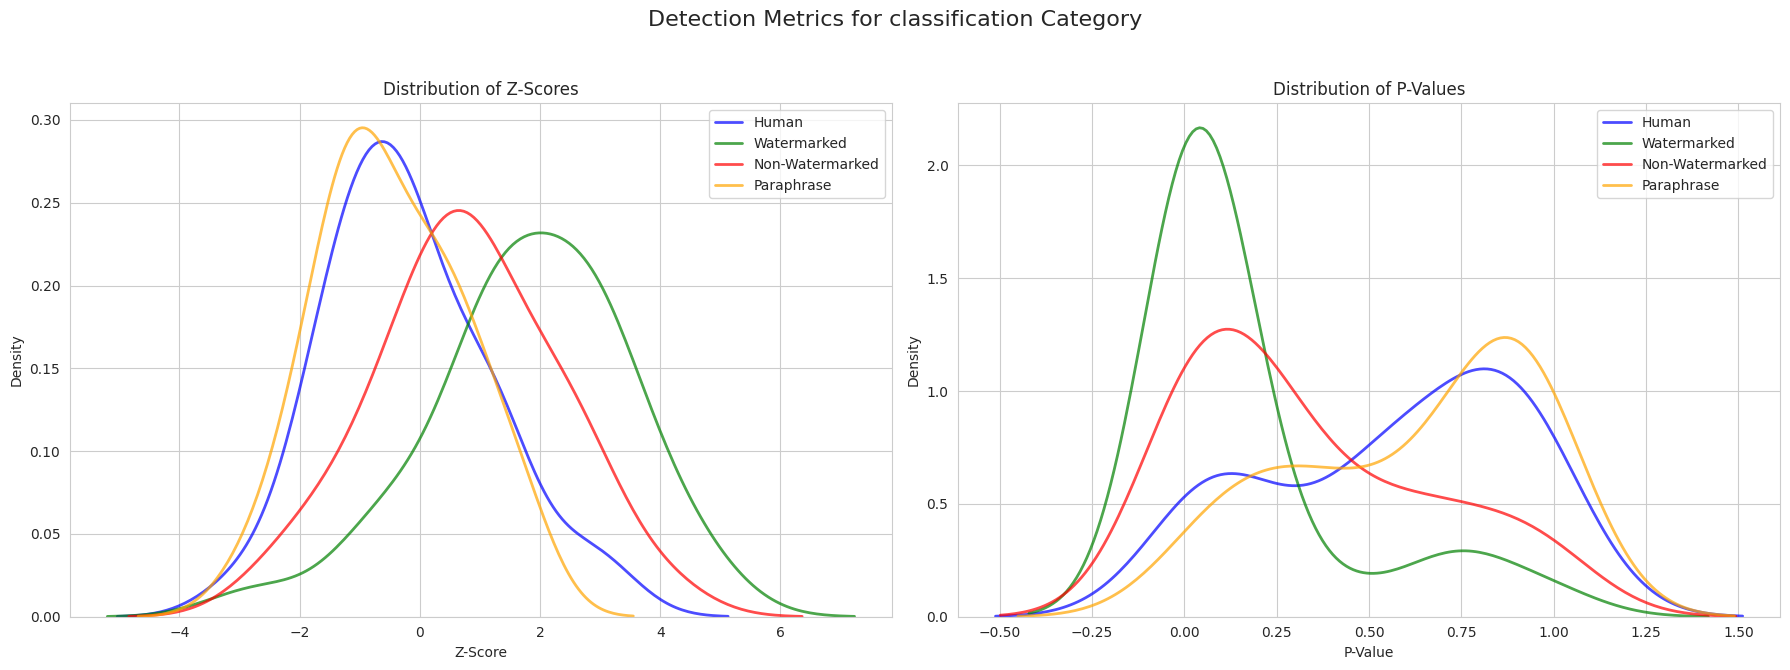


--- Visualizations for Category: creative_writing ---


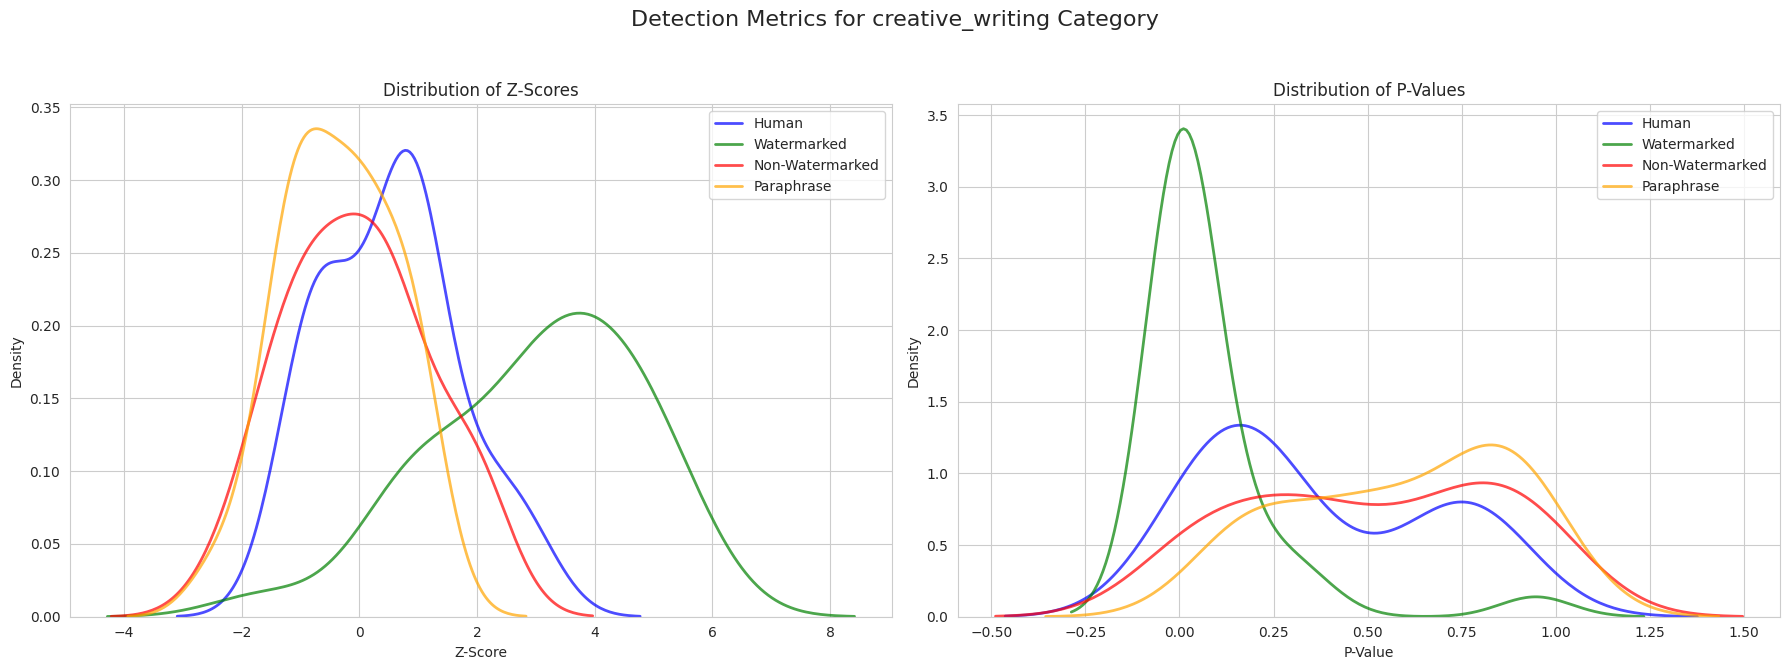

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

for category in specific_categories:
    category_df = new_evaluation_df[new_evaluation_df['category'] == category]
    if not category_df.empty:
        print(f"\n--- Visualizations for Category: {category} ---")
        fig, axes = plt.subplots(1, 2, figsize=(18, 7))
        fig.suptitle(f'Detection Metrics for {category} Category', fontsize=16)

        # Plotting Z-Scores for the current category
        sns.kdeplot(category_df['human_z_score'], color='blue', label='Human', ax=axes[0], fill=False, alpha=0.7, linewidth=2)
        sns.kdeplot(category_df['watermarked_z_score'], color='green', label='Watermarked', ax=axes[0], fill=False, alpha=0.7, linewidth=2)
        sns.kdeplot(category_df['non_watermarked_z_score'], color='red', label='Non-Watermarked', ax=axes[0], fill=False, alpha=0.7, linewidth=2)
        sns.kdeplot(category_df['paraphrase_z_score'], color='orange', label='Paraphrase', ax=axes[0], fill=False, alpha=0.7, linewidth=2)
        axes[0].set_title('Distribution of Z-Scores')
        axes[0].set_xlabel('Z-Score')
        axes[0].set_ylabel('Density')
        axes[0].legend()

        # Plotting P-Values for the current category
        sns.kdeplot(category_df['human_p_value'], color='blue', label='Human', ax=axes[1], fill=False, alpha=0.7, linewidth=2)
        sns.kdeplot(category_df['watermarked_p_value'], color='green', label='Watermarked', ax=axes[1], fill=False, alpha=0.7, linewidth=2)
        sns.kdeplot(category_df['non_watermarked_p_value'], color='red', label='Non-Watermarked', ax=axes[1], fill=False, alpha=0.7, linewidth=2)
        sns.kdeplot(category_df['paraphrase_p_value'], color='orange', label='Paraphrase', ax=axes[1], fill=False, alpha=0.7, linewidth=2)
        axes[1].set_title('Distribution of P-Values')
        axes[1].set_xlabel('P-Value')
        axes[1].set_ylabel('Density')
        axes[1].legend()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
        plt.show()
    else:
        print(f"No data to visualize for category: {category}")

### Comparing Watermarked Z-scores and P-values Across Categories

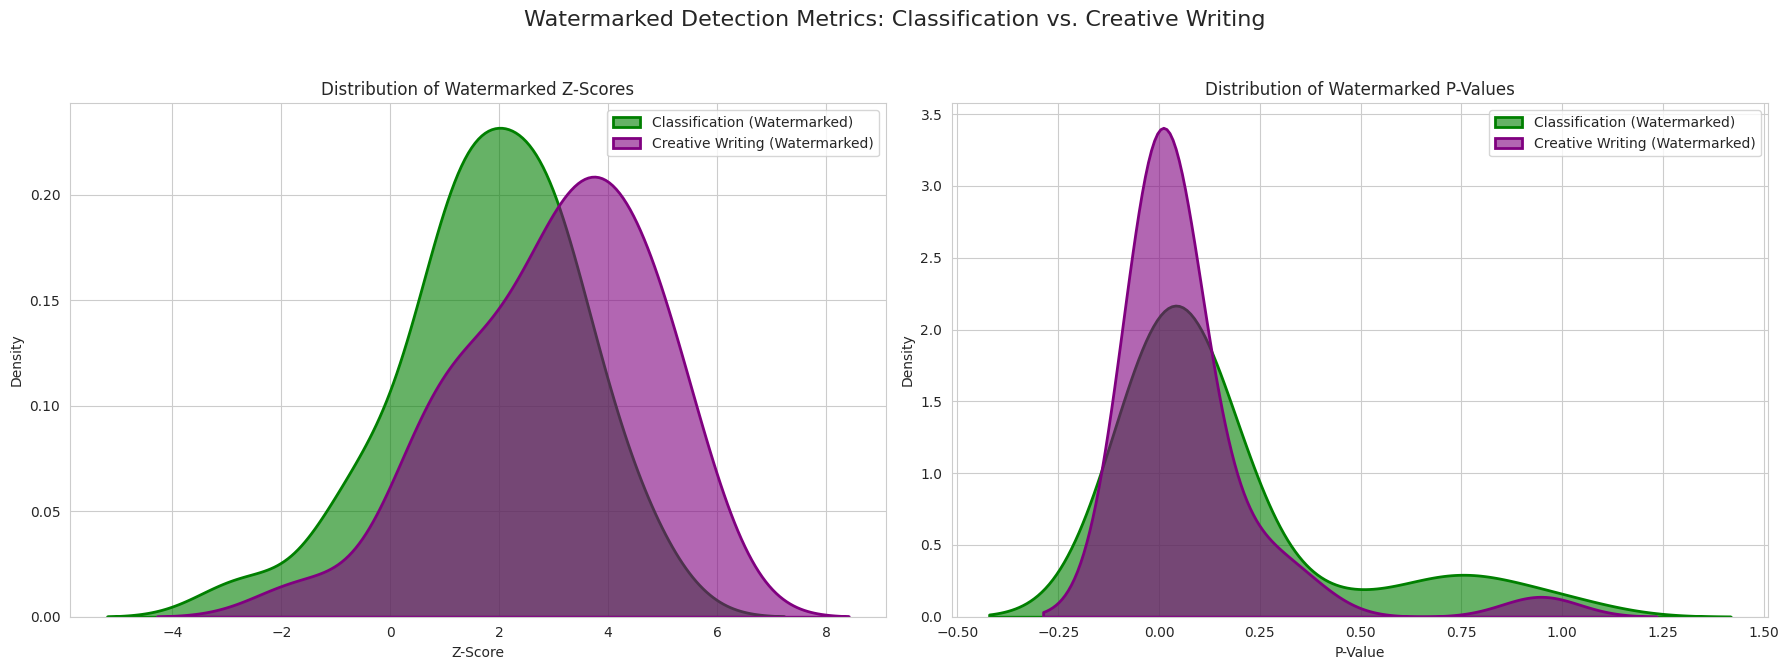

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Filter for watermarked data only
watermarked_classification_df = new_evaluation_df[(new_evaluation_df['category'] == 'classification')]
watermarked_creative_writing_df = new_evaluation_df[(new_evaluation_df['category'] == 'creative_writing')]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Watermarked Detection Metrics: Classification vs. Creative Writing', fontsize=16)

# Plotting Watermarked Z-Scores
sns.kdeplot(watermarked_classification_df['watermarked_z_score'], color='green', label='Classification (Watermarked)', ax=axes[0], fill=True, alpha=0.6, linewidth=2)
sns.kdeplot(watermarked_creative_writing_df['watermarked_z_score'], color='purple', label='Creative Writing (Watermarked)', ax=axes[0], fill=True, alpha=0.6, linewidth=2)
axes[0].set_title('Distribution of Watermarked Z-Scores')
axes[0].set_xlabel('Z-Score')
axes[0].set_ylabel('Density')
axes[0].legend()

# Plotting Watermarked P-Values
sns.kdeplot(watermarked_classification_df['watermarked_p_value'], color='green', label='Classification (Watermarked)', ax=axes[1], fill=True, alpha=0.6, linewidth=2)
sns.kdeplot(watermarked_creative_writing_df['watermarked_p_value'], color='purple', label='Creative Writing (Watermarked)', ax=axes[1], fill=True, alpha=0.6, linewidth=2)
axes[1].set_title('Distribution of Watermarked P-Values')
axes[1].set_xlabel('P-Value')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()